

---

 **Atharv Ravindra Sonawane**

 BE-B - 46

 Problem Statement : Binary classification using Deep Neural Networks Example:
Classify movie reviews into “positive" reviews and "negative" reviews, just based on the text
content of the reviews. Use the IMDB dataset.

---



In [ ]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
def vectorize(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results
X_train = vectorize(X_train)
X_test = vectorize(X_test)

In [ ]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(10000,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=512,
                    validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6787 - loss: 0.5916 - val_accuracy: 0.8476 - val_loss: 0.4499
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8954 - loss: 0.3260 - val_accuracy: 0.8854 - val_loss: 0.2960
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9301 - loss: 0.2069 - val_accuracy: 0.8948 - val_loss: 0.2729
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9479 - loss: 0.1554 - val_accuracy: 0.8892 - val_loss: 0.2870
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9628 - loss: 0.1203 - val_accuracy: 0.8882 - val_loss: 0.2992
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9726 - loss: 0.0950 - val_accuracy: 0.8834 - val_loss: 0.3240
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9819 - loss: 0.0722 - val_accuracy: 0.8790 - val_loss: 0.3557
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9880 - loss: 0.0561 - val_accuracy: 0.8772 - v

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8636 - loss: 0.5011
Test Accuracy: 0.8635600209236145


In [ ]:
predictions = model.predict(X_test)

print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {y_test[i]}, Predicted: {predictions[i][0]:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Sample Predictions:
Actual: 0, Predicted: 0.18
Actual: 1, Predicted: 1.00
Actual: 1, Predicted: 0.19
Actual: 0, Predicted: 0.55
Actual: 1, Predicted: 1.00


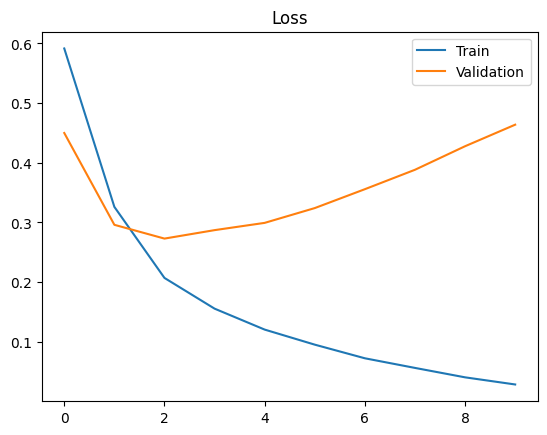

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

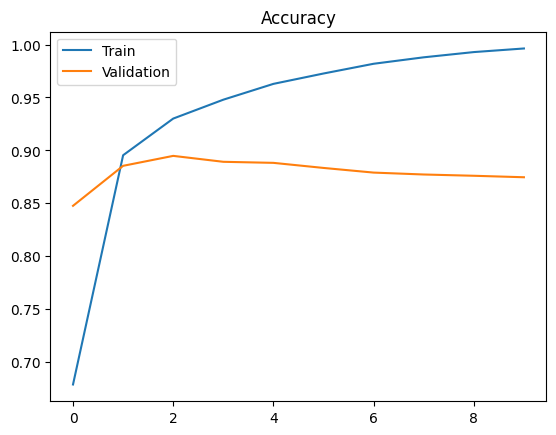

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()